1. Montar librerias

In [1]:
!pip install -q librosa soundfile

2. Montar el conjundo de datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


3. Definir ruta del dataset

In [3]:
import os

BASE = "/content/drive/MyDrive/DAIC-WOZ"

print("Existe:", os.path.exists(BASE))
print("Número de archivos:", len(os.listdir(BASE)))

Existe: True
Número de archivos: 1716


4. Comprobacion del montaje

In [4]:
import os

print(os.path.exists(BASE))
print(len(os.listdir(BASE)))

True
1716


5. Versionado en el GIT

https://github.com/fabiovanegas/Delphin2026.git/

6. Explorar contenido del dataset

In [5]:
for archivo in os.listdir(BASE)[:50]:
    print(archivo)

429_COVAREP.csv
429_FORMANT.csv
431_COVAREP.csv
431_FORMANT.csv
434_COVAREP.csv
434_FORMANT.csv
435_COVAREP.csv
435_FORMANT.csv
447_COVAREP.csv
447_FORMANT.csv
448_COVAREP.csv
448_FORMANT.csv
449_COVAREP.csv
449_FORMANT.csv
450_COVAREP.csv
450_FORMANT.csv
457_COVAREP.csv
457_FORMANT.csv
459_COVAREP.csv
459_FORMANT.csv
465_COVAREP.csv
465_FORMANT.csv
466_COVAREP.csv
466_FORMANT.csv
467_COVAREP.csv
467_FORMANT.csv
469_COVAREP.csv
469_FORMANT.csv
470_COVAREP.csv
470_FORMANT.csv
474_COVAREP.csv
474_FORMANT.csv
477_COVAREP.csv
477_FORMANT.csv
478_COVAREP.csv
478_FORMANT.csv
481_COVAREP.csv
481_FORMANT.csv
488_COVAREP.csv
488_FORMANT.csv
306_COVAREP.csv
306_FORMANT.csv
300_TRANSCRIPT.csv
301_TRANSCRIPT.csv
303_TRANSCRIPT.csv
305_TRANSCRIPT.csv
306_TRANSCRIPT.csv
308_TRANSCRIPT.csv
300_CLNF_AUs.txt
300_CLNF_features.txt


7. Configuración general

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

8. Cargar etiquetas PHQ-8

In [7]:
df = pd.read_csv(
    f"{BASE}/dev_split_Depression_AVEC2017.csv"
)

print(df.head())
print(df.shape)
print(df.columns.tolist())

   Participant_ID  PHQ8_Binary  PHQ8_Score  Gender  PHQ8_NoInterest  \
0             302            0           4       1                1   
1             307            0           4       0                0   
2             331            0           8       1                1   
3             335            1          12       0                1   
4             346            1          23       0                2   

   PHQ8_Depressed  PHQ8_Sleep  PHQ8_Tired  PHQ8_Appetite  PHQ8_Failure  \
0               1           0           1              0             1   
1               1           0           1              0             2   
2               1           1           1              1             1   
3               1           3           2              3             1   
4               3           3           3              3             3   

   PHQ8_Concentrating  PHQ8_Moving  
0                   0            0  
1                   0            0  
2                

9. Información genera

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Participant_ID      35 non-null     int64
 1   PHQ8_Binary         35 non-null     int64
 2   PHQ8_Score          35 non-null     int64
 3   Gender              35 non-null     int64
 4   PHQ8_NoInterest     35 non-null     int64
 5   PHQ8_Depressed      35 non-null     int64
 6   PHQ8_Sleep          35 non-null     int64
 7   PHQ8_Tired          35 non-null     int64
 8   PHQ8_Appetite       35 non-null     int64
 9   PHQ8_Failure        35 non-null     int64
 10  PHQ8_Concentrating  35 non-null     int64
 11  PHQ8_Moving         35 non-null     int64
dtypes: int64(12)
memory usage: 3.4 KB


10. Balance de clases

PHQ8_Binary
0    23
1    12
Name: count, dtype: int64


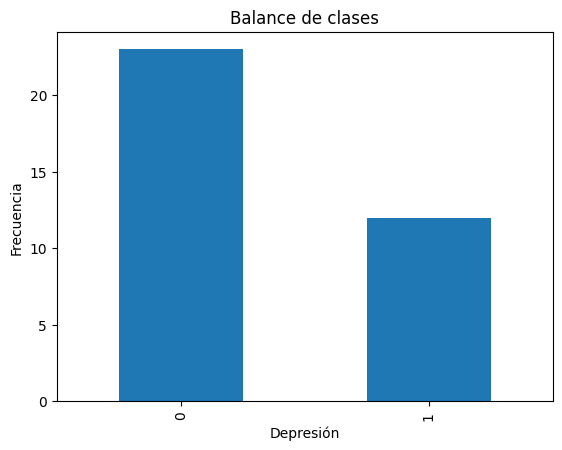

In [9]:
print(df["PHQ8_Binary"].value_counts())

df["PHQ8_Binary"].value_counts().plot(
    kind="bar"
)

plt.title("Balance de clases")
plt.xlabel("Depresión")
plt.ylabel("Frecuencia")
plt.show()


11. Distribución PHQ-8

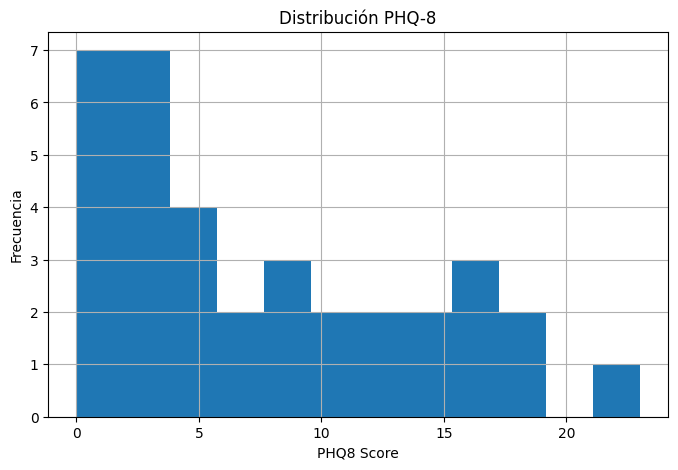

In [10]:
plt.figure(figsize=(8,5))

df["PHQ8_Score"].hist(
    bins=12
)

plt.title("Distribución PHQ-8")
plt.xlabel("PHQ8 Score")
plt.ylabel("Frecuencia")

plt.show()

12. Distribución por género

Gender
0    19
1    16
Name: count, dtype: int64


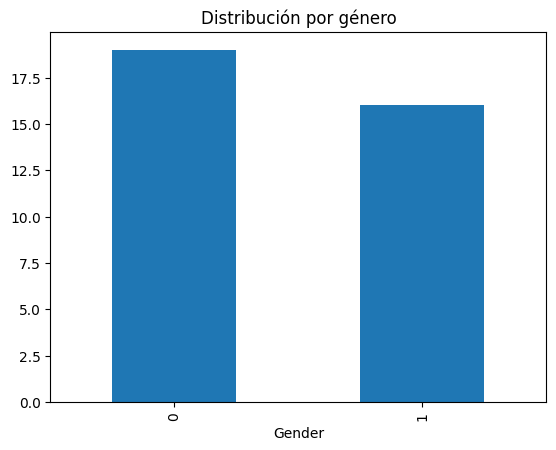

In [11]:
print(df["Gender"].value_counts())

df["Gender"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución por género")
plt.show()

13. Distribución del puntaje total PHQ-8

count    35.000000
mean      7.428571
std       6.590036
min       0.000000
25%       2.000000
50%       5.000000
75%      12.000000
max      23.000000
Name: PHQ8_Score, dtype: float64


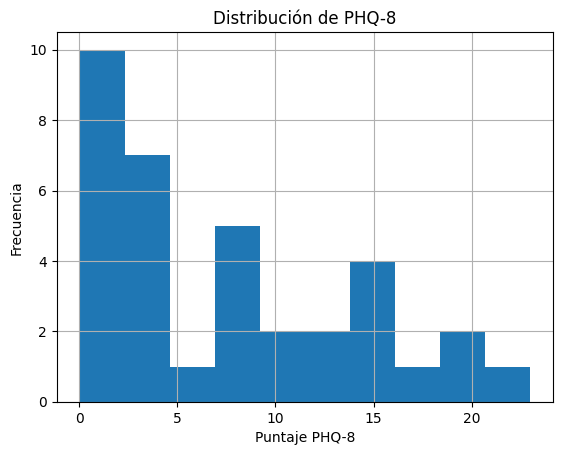

In [12]:
print(df["PHQ8_Score"].describe())

df["PHQ8_Score"].hist(
    bins=10
)

plt.title("Distribución de PHQ-8")
plt.xlabel("Puntaje PHQ-8")
plt.ylabel("Frecuencia")
plt.show()

14. Cargar transcripción

In [13]:
transcript = pd.read_csv(
    f"{BASE}/300_TRANSCRIPT.csv",
    sep="\t"
)

print(transcript.columns)
transcript.head()

Index(['start_time', 'stop_time', 'speaker', 'value'], dtype='object')


,start_time,stop_time,speaker,value
0,36.588,39.668,Ellie,hi i'm ellie thanks for coming in today
1,39.888,43.378,Ellie,i was created to talk to people in a safe and ...
2,43.728,48.498,Ellie,think of me as a friend i don't judge i can't ...
3,49.188,52.388,Ellie,i'm here to learn about people and would love ...
4,52.658,58.958,Ellie,i'll ask a few questions to get us started and...


15. Filtrar respuestas del participante

In [14]:
participant = transcript[
    transcript["speaker"] == "Participant"
]

participant.head()

,start_time,stop_time,speaker,value
6,62.328,63.178,Participant,good
9,68.978,70.288,Participant,atlanta georgia
12,75.028,78.128,Participant,um my parents are from here um
14,83.808,84.588,Participant,i love it
16,88.458,89.968,Participant,i like the weather


16. Número de intervenciones

In [15]:
print(
    "Número de intervenciones:",
    len(participant)
)

Número de intervenciones: 87


17. Longitud de respuestas

In [16]:
participant["num_palabras"] = (
    participant["value"]
    .astype(str)
    .str.split()
    .str.len()
)

participant.head()

/tmp/ipykernel_4025/4149310848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  participant["num_palabras"] = (


,start_time,stop_time,speaker,value,num_palabras
6,62.328,63.178,Participant,good,1
9,68.978,70.288,Participant,atlanta georgia,2
12,75.028,78.128,Participant,um my parents are from here um,7
14,83.808,84.588,Participant,i love it,3
16,88.458,89.968,Participant,i like the weather,4


18. Estadísticas del texto

In [17]:
participant["num_palabras"].describe()

,num_palabras
count,87.000000
mean,4.045977
std,3.725800
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,20.000000


19. Histograma de longitud

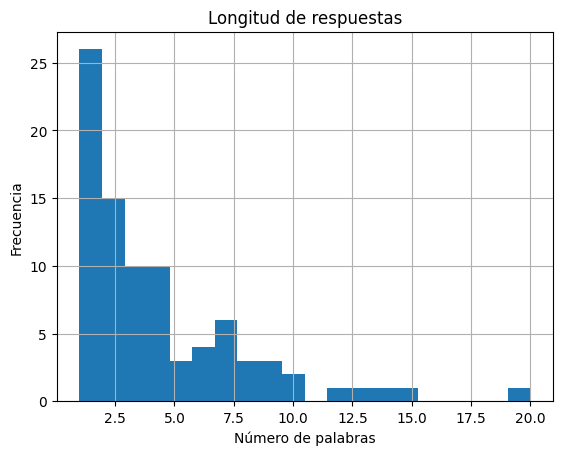

In [18]:
participant["num_palabras"].hist(
    bins=20
)

plt.title(
    "Longitud de respuestas"
)

plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")

plt.show()

20. Total de palabras

21. Cargar audio

In [19]:
import librosa

audio, sr = librosa.load(
    f"{BASE}/300_AUDIO.wav",
    sr=None
)

print(audio.shape)
print(sr)

(10376000,)
16000


22. Duración del audio

In [20]:
duracion = librosa.get_duration(
    y=audio,
    sr=sr
)

print(
    f"Duración: {duracion:.2f} segundos"
)

print(
    f"Duración: {duracion/60:.2f} minutos"
)

Duración: 648.50 segundos
Duración: 10.81 minutos


23. Visualización de la señal

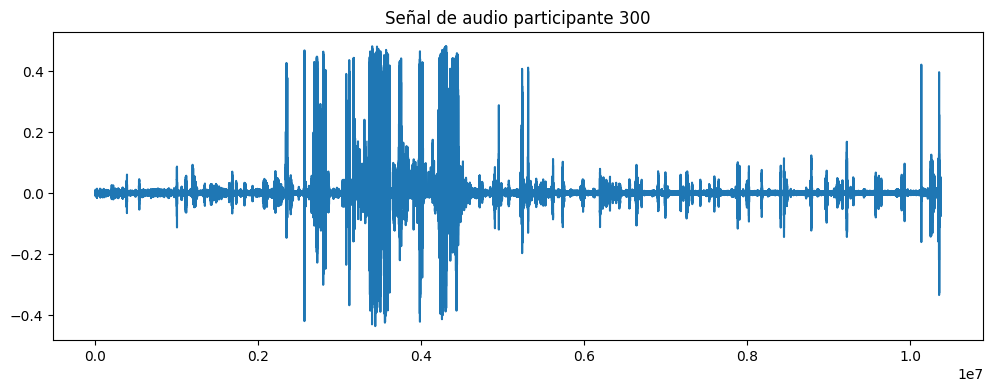

In [21]:
plt.figure(figsize=(12,4))

plt.plot(audio)

plt.title(
    "Señal de audio participante 300"
)

plt.show()

24. Estadísticas descriptivas

In [22]:
df.describe(include="all")

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,416.057143,0.342857,7.428571,0.457143,0.657143,0.942857,1.200000,1.314286,1.085714,1.000000,0.828571,0.400000
std,53.680944,0.481594,6.590036,0.505433,0.838165,0.937546,1.255576,1.078436,1.147156,1.188177,1.097744,0.774597
min,302.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,385.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
50%,417.000000,0.000000,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,465.000000,1.000000,12.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.500000
max,492.000000,1.000000,23.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000


25. Conclusiones (Markdown)

# Conclusiones

- Se exploró la estructura general del corpus DAIC-WOZ.
- Se verificó la existencia de archivos de audio y transcripciones.
- Se analizaron las etiquetas PHQ utilizadas para medir depresión.
- Se observó la distribución de participantes según presencia o ausencia de depresión.
- Se analizaron las características textuales de las transcripciones.
- Se verificó la correcta carga y visualización de archivos de audio.
- Se configuró un entorno reproducible en Google Colab y GitHub para las siguientes etapas del proyecto.